# Metrics Analysis for Chat (Ad-Hoc) Agent with Qwen-3-Instruct Model running on Tensorrt-llm

## Raw Results 

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../output/chat_raw_q3_trtllm.csv')

# Inspect the first few rows and the column names
print(df.info())
print(df.head())

# Check unique values in the column that likely holds the system prompt reference
# Based on the snippet, it's 'redis_optimization_reference'
if 'redis_optimization_reference' in df.columns:
    print("\nUnique prompt references:")
    print(df['redis_optimization_reference'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 37 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   batch_file                            96 non-null     object 
 1   environment_remarks                   89 non-null     object 
 2   evidence_0                            96 non-null     object 
 3   evidence_1                            96 non-null     object 
 4   evidence_2                            52 non-null     object 
 5   evidence_3                            1 non-null      object 
 6   failure_attribution                   96 non-null     object 
 7   faithfulness                          96 non-null     float64
 8   has_payload                           96 non-null     bool   
 9   issues                                31 non-null     object 
 10  issues_0                              65 non-null     object 
 11  issues_1             

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the latest prompt reference
latest_prompt = 'system-prompts:chat:20260427T001031Z'
latest_batch = 'batches__jvjkpc6c6e4b0cgap8a6ql3ysd0h97g7vwkl.jsonl'

# Filter the dataframe
df_latest = df[(df['redis_optimization_reference'] == latest_prompt) & (df['batch_file']==latest_batch) ].copy()
# & (df['batch_file']==latest_batch)

# 1. Basic Summary Statistics for the latest prompt
stats_latest = {
    'Count': len(df_latest),
    'Avg Overall Score': df_latest['overall_score'].mean(),
    'Avg Plan Adherence': df_latest['plan_adherence'].mean(),
    'Task Completion Rate': df_latest['task_completion'].mean(),
    'Average Faithfulness': df_latest['faithfulness'].mean(),
    'Average Step Efficiency': df_latest['step_efficiency'].mean(),
    'Avg Tool Accuracy': df_latest['tool_accuracy'].mean(),
    'Avg Workflow Latency': df_latest['redis_stats_workflow_latency'].mean(),
    'Avg Total Token Cost': df_latest['redis_stats_task_total_token_cost'].mean()
}

print("Summary Statistics for Latest Prompt (20260428T063643Z):")
for k, v in stats_latest.items():
    print(f"{k}: {v:.2f}")

# 2. Verdict Distribution
verdict_counts = df_latest['verdict'].value_counts()

# 3. Failure Attribution for non-pass verdicts
failure_attribution = df_latest[df_latest['verdict'] != 'pass']['failure_attribution'].value_counts()



Summary Statistics for Latest Prompt (20260428T063643Z):
Count: 25.00
Avg Overall Score: 8.24
Avg Plan Adherence: 0.92
Task Completion Rate: 0.78
Average Faithfulness: 0.98
Average Step Efficiency: 0.85
Avg Tool Accuracy: 0.88
Avg Workflow Latency: 31.50
Avg Total Token Cost: 12454.68


In [3]:
df_latest

,batch_file,environment_remarks,evidence_0,evidence_1,evidence_2,evidence_3,failure_attribution,faithfulness,has_payload,issues,...,redis_stats_workflow_latency,step_efficiency,strengths_0,strengths_1,strengths_2,summary,task_completion,tool_accuracy,verdict,workflow_key
25,batches__jvjkpc6c6e4b0cgap8a6ql3ysd0h97g7vwkl....,No failure occurred; the agent successfully pe...,Function call: kubernetes-list-workloads with ...,Function execution result: returned empty coun...,NaN,NaN,agent,1.0,True,[],...,18.027192,1.00,Correctly utilized the specialized tool `kuber...,Properly handled the injected `workflow_id` in...,"Provided a clear, concise, and accurate report...","The agent correctly identified the namespace, ...",1.0,1.00,pass,d02aee10-ebe6-403a-b6a8-3b6a82029005
26,batches__jvjkpc6c6e4b0cgap8a6ql3ysd0h97g7vwkl....,The failure to find the release is environment...,"helm-list-releases returned {""success"": true, ...","helm-test returned {""success"": false, ""message...",NaN,NaN,agent,1.0,True,NaN,...,20.038923,0.80,Correctly verified namespace and release exist...,Accurately reported the failure to find the re...,NaN,The agent correctly identified that the reques...,0.0,0.66,partial,07c03905-13fc-4e52-b9b9-db72f5e585b6
27,batches__jvjkpc6c6e4b0cgap8a6ql3ysd0h97g7vwkl....,No failure occurred; the agent correctly repor...,kubernetes-resources_get returned 'deployments...,kubernetes-list-workloads returned a summary w...,NaN,NaN,agent,1.0,True,[],...,17.286824,1.00,Logical sequence of operations: namespace veri...,Correct handling of the workflow_id injection ...,NaN,The agent correctly identified the absence of ...,1.0,1.00,pass,6d4debff-5f3d-44b1-9c7a-3f6ec9b4a67f
28,batches__jvjkpc6c6e4b0cgap8a6ql3ysd0h97g7vwkl....,No failures occurred.,helm-list-releases returned two releases in th...,helm-get-values output confirmed that image ta...,NaN,NaN,agent,1.0,True,[],...,26.006750,1.00,Followed the requested workflow and tool seque...,Provided a concise and insightful summary of t...,Correctly handled the workflow_id injection.,The agent successfully inspected the Helm rele...,1.0,1.00,pass,029aa1e7-1114-4cbd-a370-a6dec1d3bbd1
29,batches__jvjkpc6c6e4b0cgap8a6ql3ysd0h97g7vwkl....,The initial failure was caused by the agent's ...,kubernetes-list-workloads returned empty resul...,kafka-produce-message failed with 'Expecting '...,Second attempt at kafka-produce-message succee...,NaN,agent,1.0,True,NaN,...,24.541003,0.80,Correctly identified the need to verify resour...,Successfully recovered from a malformed JSON p...,NaN,The agent successfully performed the requested...,1.0,0.90,pass,197a4028-cc73-4a94-8b33-7ccbbba8a6fd
30,batches__jvjkpc6c6e4b0cgap8a6ql3ysd0h97g7vwkl....,The failure to collect metrics was primarily d...,kubernetes-list-workloads returned count 0 for...,resource-collector call for CPU metrics used '...,resource-collector call for memory metrics ret...,NaN,agent,1.0,True,NaN,...,28.922007,0.80,Correctly followed the multi-step plan of list...,Accurately reported the empty state of the nam...,NaN,The agent correctly identified that the namesp...,0.5,0.66,partial,63154ee2-b48a-4b1e-b711-ef6d0d8152d0
31,batches__jvjkpc6c6e4b0cgap8a6ql3ysd0h97g7vwkl....,The environment functioned correctly; the agen...,Function execution 1 returned empty releases f...,Function execution 2 identified four releases ...,The agent's final report states 'a helm-get-va...,NaN,agent,1.0,True,NaN,...,37.305708,0.80,Correctly handled the empty result in the targ...,Properly injected the required workflow_id int...,NaN,The agent correctly identified that no release...,0.5,1.00,partial,c284f720-80e8-4828-95b4-f76731c6bb9b
32,batches__jvjkpc6c6e4b0cgap8a6ql3ysd0h97g7vwkl....,The task was completed successfully according ...,kubernetes-list-workloads returned an empty su...,The agent correctly concluded that no action c...,NaN,NaN,agent,1.0,True,[],...,9.992065,1.00,Strict adherence to safety guardrails by verif...,Accurate reporting of the empty state


Visualizations saved: verdict_distribution.png, score_distribution.png, prompt_comparison.png, success_comparison.png


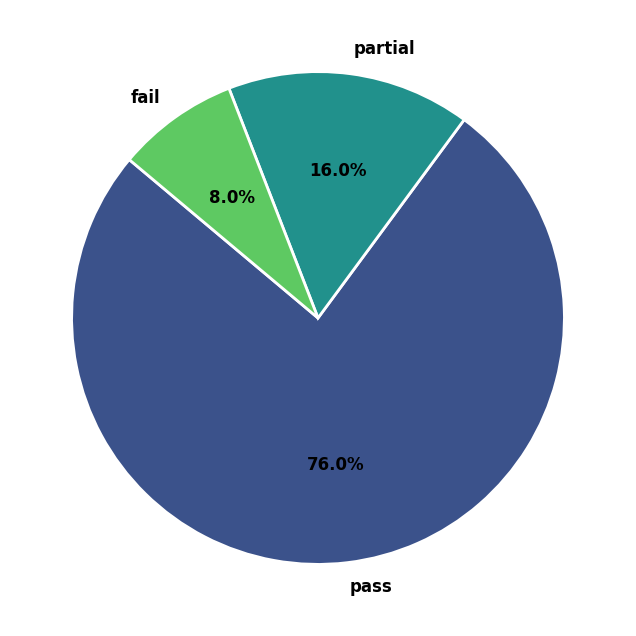

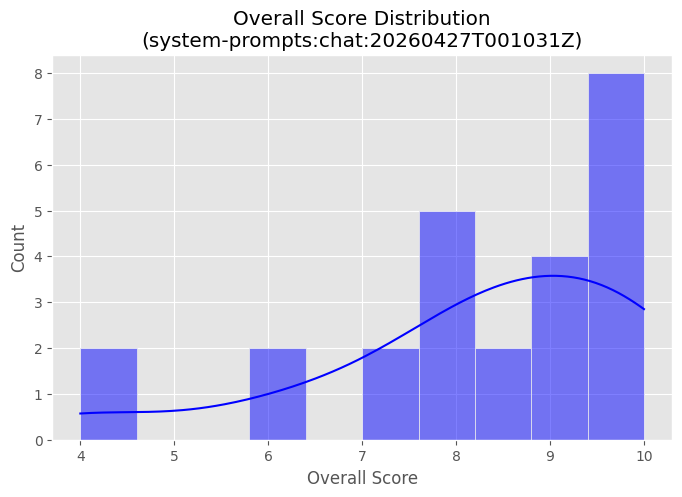

In [4]:
# Visualizations
plt.style.use('ggplot')

# Plot 1: Verdict Distribution
plt.figure(figsize=(8, 8))
colors = sns.color_palette('viridis', len(verdict_counts))

plt.pie(
    verdict_counts, 
    labels=verdict_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# Plot 2: Overall Score Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_latest['overall_score'], bins=10, kde=True, color='blue')
plt.title(f'Overall Score Distribution\n({latest_prompt})')
plt.xlabel('Overall Score')
plt.savefig('score_distribution.png')

# # Plot 3: Comparison of Average Score across all prompts
# prompt_comparison = df.groupby('redis_optimization_reference')['overall_score'].mean().sort_values()
# plt.figure(figsize=(10, 6))
# prompt_comparison.plot(kind='barh', color='skyblue')
# plt.axvline(df_latest['overall_score'].mean(), color='red', linestyle='--', label='Latest Prompt Avg')
# plt.title('Average Overall Score by System Prompt Reference')
# plt.xlabel('Mean Overall Score')
# plt.ylabel('Prompt Reference')
# plt.legend()
# plt.tight_layout()
# plt.savefig('prompt_comparison.png')

# # Plot 4: Success Rate (Task Completion) by Prompt
# success_comparison = df.groupby('redis_optimization_reference')['task_completion'].mean().sort_values()
# plt.figure(figsize=(10, 6))
# success_comparison.plot(kind='barh', color='lightgreen')
# plt.title('Task Completion Rate by System Prompt Reference')
# plt.xlabel('Mean Task Completion Rate')
# plt.ylabel('Prompt Reference')
# plt.tight_layout()
# plt.savefig('success_comparison.png')

print("\nVisualizations saved: verdict_distribution.png, score_distribution.png, prompt_comparison.png, success_comparison.png")

      overall_score  plan_adherence  redis_stats_workflow_latency  \
mean       8.240000        0.916000                     31.498642   
std        1.750714        0.179536                     13.321596   
min        4.000000        0.400000                      9.992065   
max       10.000000        1.000000                     59.512241   

      redis_stats_task_total_token_cost  
mean                       12454.680000  
std                          153.224704  
min                        12239.000000  
max                        12871.000000  


/tmp/ipykernel_2077518/318958129.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_latest, x='verdict', y='redis_stats_workflow_latency', palette='Set2')


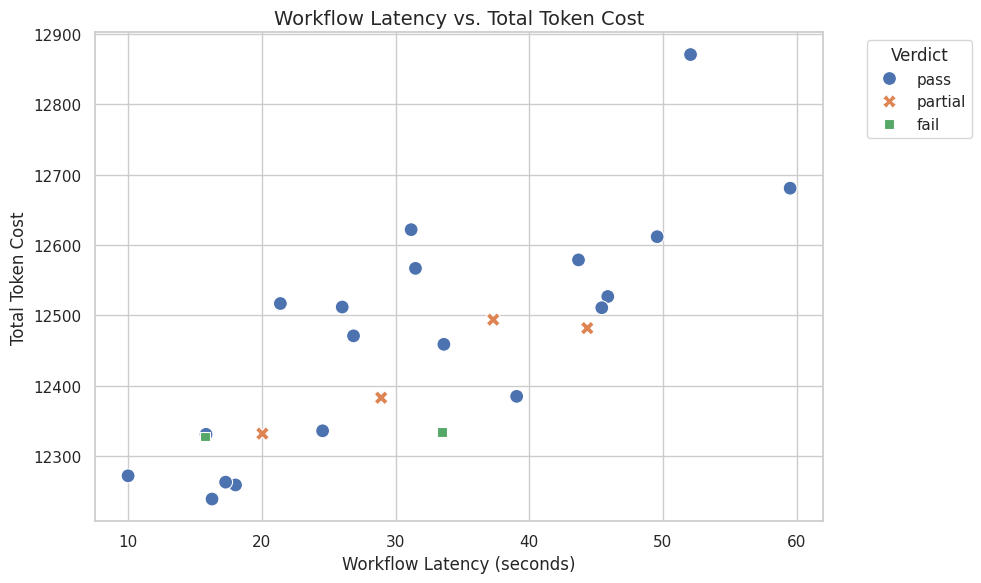

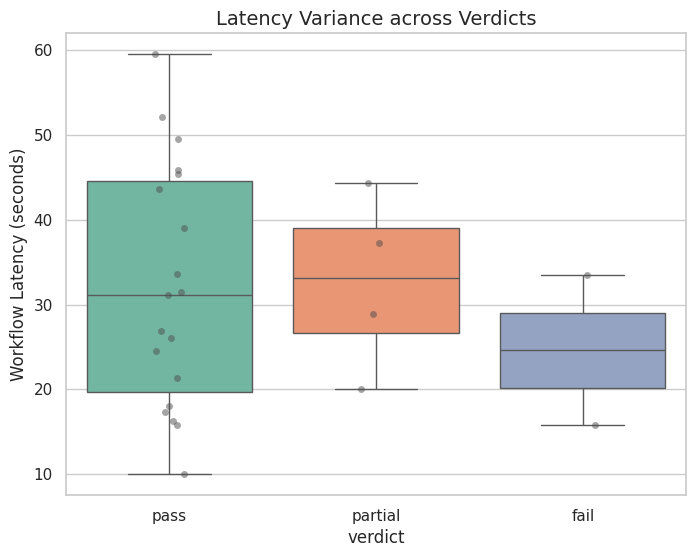

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set aesthetic parameters for Seaborn
sns.set_theme(style="whitegrid")

# Load data

# Define the target prompt reference
df_latest = df[df['redis_optimization_reference'] == latest_prompt].copy()

# # 1. Performance Comparison: Average Score by Prompt Version
# plt.figure(figsize=(12, 6))
# avg_scores = df.groupby('redis_optimization_reference')['overall_score'].mean().sort_values(ascending=False).reset_index()
# sns.barplot(data=avg_scores, y='redis_optimization_reference', x='overall_score', palette='mako')
# plt.title('Average Overall Score across Prompt Versions', fontsize=15)
# plt.xlabel('Mean Overall Score')
# plt.ylabel('Prompt Reference')
# plt.tight_layout()
# plt.savefig('seaborn_prompt_comparison.png')

# # 2. Verdict Distribution for the Latest Prompt
# plt.figure(figsize=(8, 6))
# sns.countplot(data=df_latest, x='verdict', order=['pass', 'partial', 'fail'], palette='viridis')
# plt.title(f'Verdict Distribution\n({latest_prompt})', fontsize=14)
# plt.ylabel('Count')
# plt.xlabel('Verdict')
# plt.savefig('seaborn_verdict_dist.png')

# 3. Latency vs. Token Cost (Efficiency Analysis)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_latest, x='redis_stats_workflow_latency', y='redis_stats_task_total_token_cost', 
                hue='verdict', style='verdict', s=100, palette='deep')
plt.title('Workflow Latency vs. Total Token Cost', fontsize=14)
plt.xlabel('Workflow Latency (seconds)')
plt.ylabel('Total Token Cost')
plt.legend(title='Verdict', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('seaborn_latency_cost_scatter.png')

# # 4. Distribution of Scores for the Latest Prompt
# plt.figure(figsize=(8, 6))
# sns.histplot(df_latest['overall_score'], kde=True, color='teal', bins=10)
# plt.title(f'Distribution of Overall Scores\n({latest_prompt})', fontsize=14)
# plt.xlabel('Overall Score')
# plt.savefig('seaborn_score_hist.png')

# 5. Boxplot of Latency by Verdict
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_latest, x='verdict', y='redis_stats_workflow_latency', palette='Set2')
sns.stripplot(data=df_latest, x='verdict', y='redis_stats_workflow_latency', color=".3", alpha=0.5)
plt.title('Latency Variance across Verdicts', fontsize=14)
plt.ylabel('Workflow Latency (seconds)')
plt.savefig('seaborn_latency_boxplot.png')

# Output some summary data for the final text response
latest_stats = df_latest.describe().loc[['mean', 'std', 'min', 'max']]
print(latest_stats[['overall_score', 'plan_adherence', 'redis_stats_workflow_latency', 'redis_stats_task_total_token_cost']])

/tmp/ipykernel_2077518/3242039449.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2077518/3242039449.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


                                      avg_score  pass_rate  sample_size
redis_optimization_reference                                           
system-prompts:chat:20260420T120754Z       7.26       0.52           25
system-prompts:chat:20260422T135758Z       8.06       0.68           25
system-prompts:chat:20260427T001031Z       8.24       0.76           25


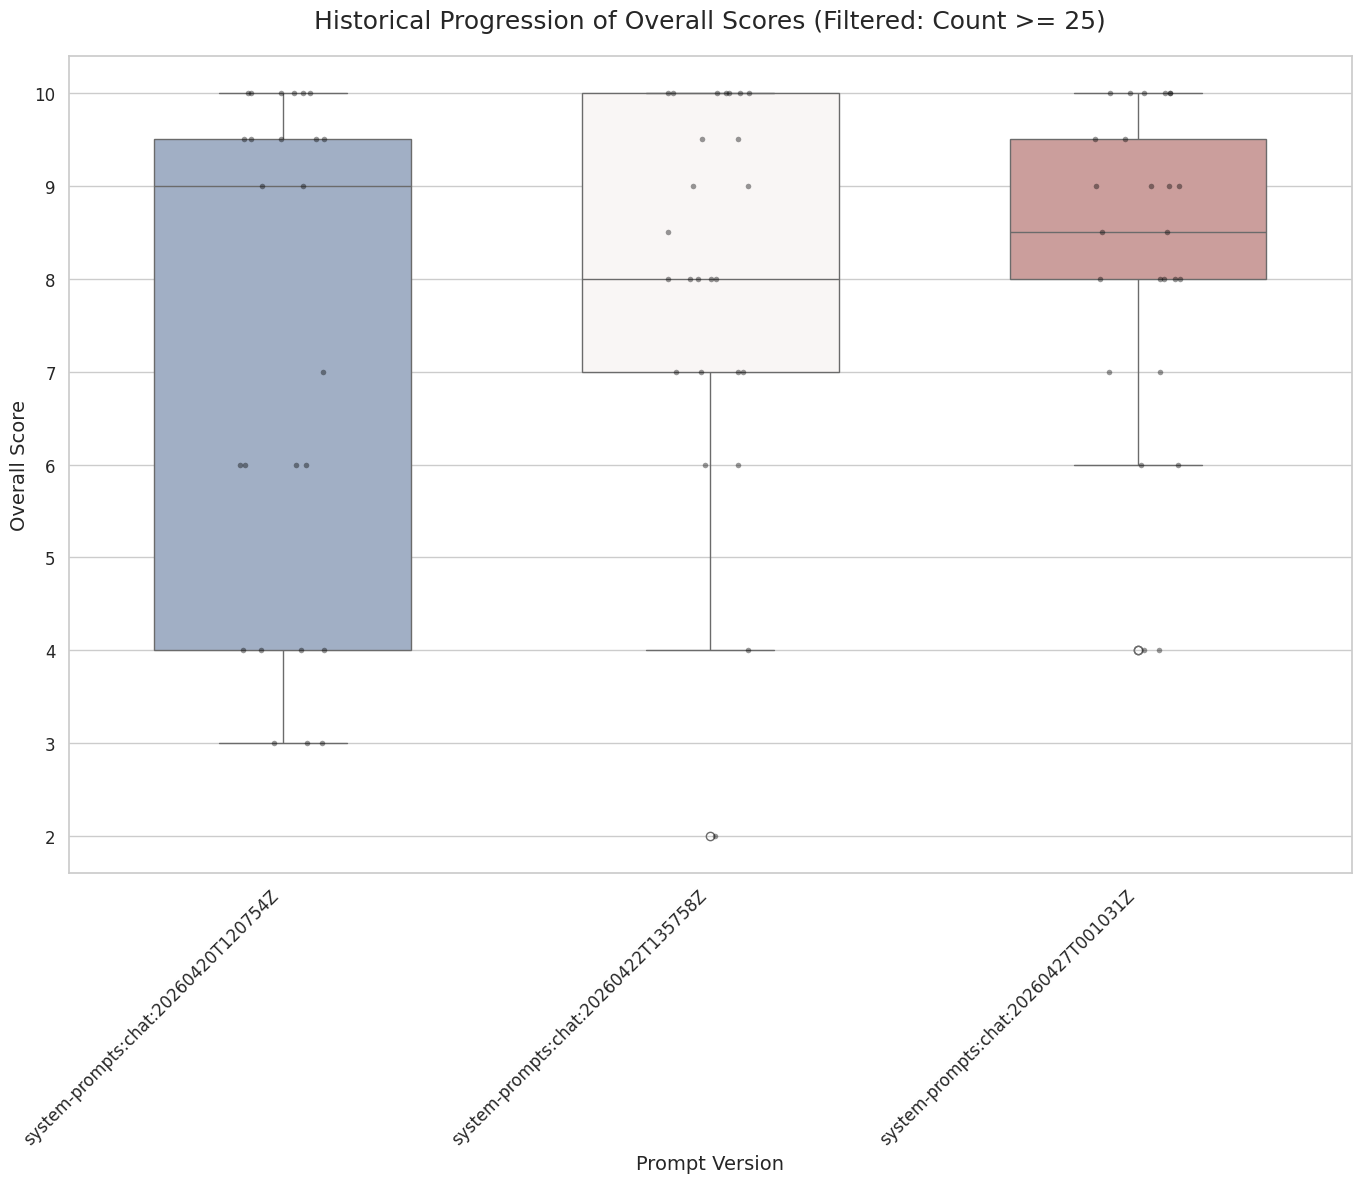

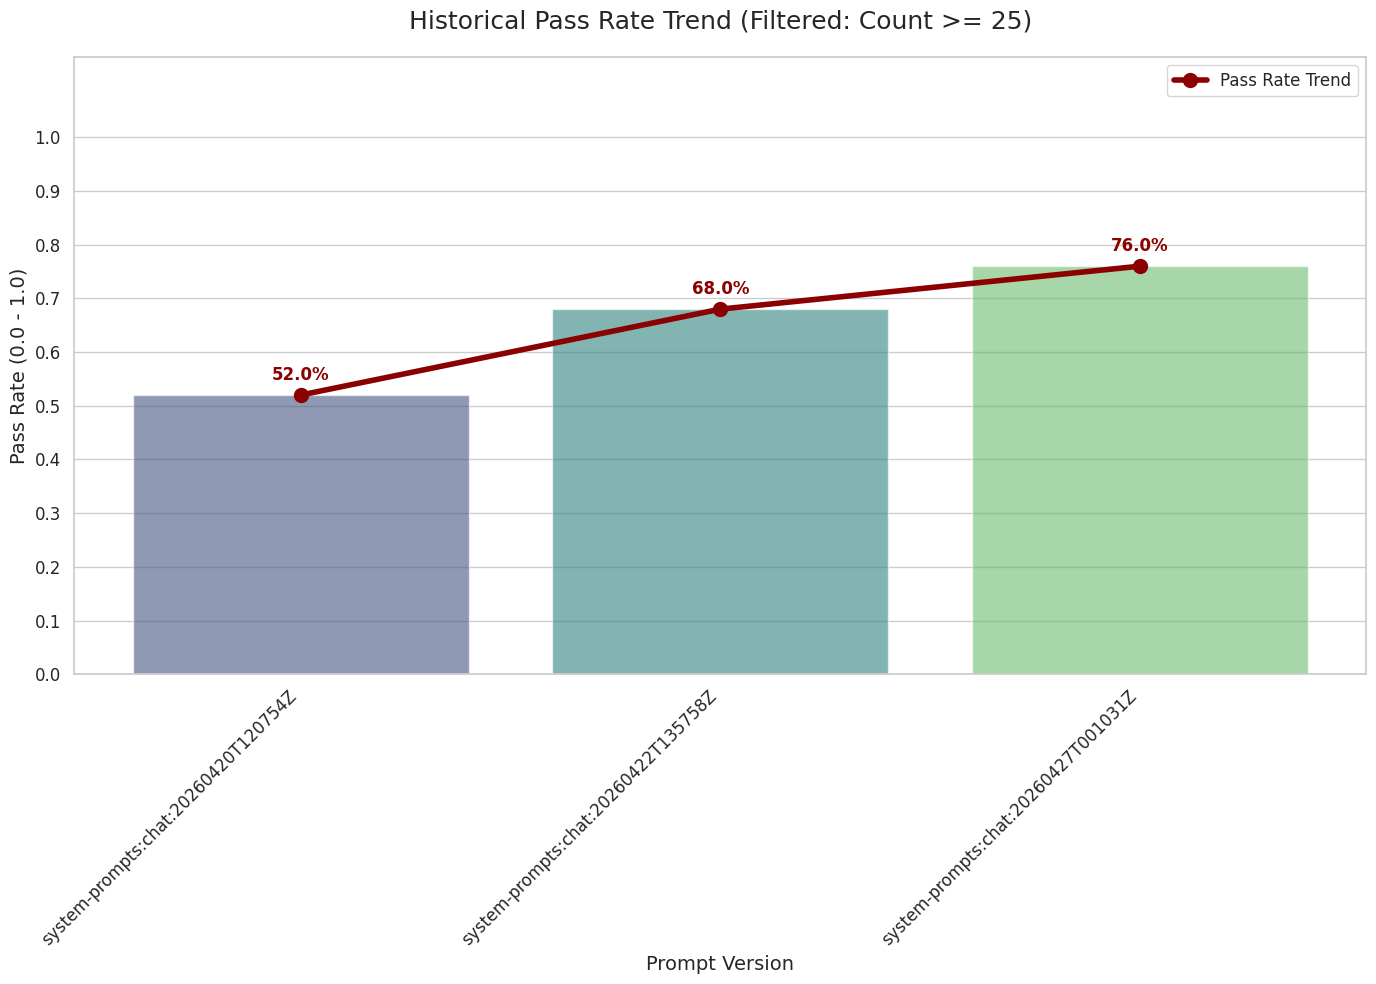

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set theme
sns.set_theme(style="whitegrid")

# Load the data

# 1. Filter out batches with count < 25
counts = df['redis_optimization_reference'].value_counts()
valid_prompts = counts[counts >= 25].index
df_filtered = df[df['redis_optimization_reference'].isin(valid_prompts)].copy()

# 2. Sort chronologically
def get_sort_key(prompt):
    if 'base' in prompt:
        return '00000000T000000Z'
    return prompt.split(':')[-1]

df_filtered['sort_key'] = df_filtered['redis_optimization_reference'].apply(get_sort_key)
sorted_prompts = df_filtered.sort_values('sort_key')['redis_optimization_reference'].unique()

# Summary table for text
summary = df_filtered.groupby('redis_optimization_reference').agg(
    avg_score=('overall_score', 'mean'),
    pass_rate=('verdict', lambda x: (x == 'pass').sum() / len(x)),
    sample_size=('overall_score', 'count')
).reindex(sorted_prompts)

# 3. Enhanced Boxplot (Taller)
plt.figure(figsize=(14, 12)) # Increased height significantly
sns.boxplot(
    data=df_filtered, 
    x='redis_optimization_reference', 
    y='overall_score', 
    order=sorted_prompts,
    palette='vlag',
    width=0.6
)
sns.stripplot(
    data=df_filtered, 
    x='redis_optimization_reference', 
    y='overall_score', 
    order=sorted_prompts,
    color='black', 
    alpha=0.4, 
    size=4
)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Historical Progression of Overall Scores (Filtered: Count >= 25)', fontsize=18, pad=20)
plt.xlabel('Prompt Version', fontsize=14)
plt.ylabel('Overall Score', fontsize=14)
plt.tight_layout()
plt.savefig('historical_scores_boxplot_tall.png')

# 4. Enhanced Pass Rate Progression (Taller)
pass_rates = summary.reset_index()
pass_rates.columns = ['prompt', 'avg_score', 'pass_rate', 'sample_size']

plt.figure(figsize=(14, 10)) # Increased height
# Bar plot
sns.barplot(
    data=pass_rates, 
    x='prompt', 
    y='pass_rate', 
    palette='viridis',
    alpha=0.6,
    order=sorted_prompts
)
# Line plot with bold markers
plt.plot(
    np.arange(len(pass_rates)), 
    pass_rates['pass_rate'], 
    marker='o', 
    color='darkred', 
    linewidth=4, 
    markersize=10, 
    label='Pass Rate Trend'
)

# Annotate the trend line with percentages
for i, rate in enumerate(pass_rates['pass_rate']):
    plt.text(i, rate + 0.02, f'{rate:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='darkred')

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=12)
plt.title('Historical Pass Rate Trend (Filtered: Count >= 25)', fontsize=18, pad=20)
plt.xlabel('Prompt Version', fontsize=14)
plt.ylabel('Pass Rate (0.0 - 1.0)', fontsize=14)
plt.ylim(0, 1.15) # Leave room for labels
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('historical_pass_rate_tall.png')

print(summary)

In [7]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Load the data files
df_raw = df 
df_meta = pd.read_csv('../output/system_prompts_chat.csv')
df_meta

# 1. Clean metadata: Merge the two potential parent columns
# The colon at the end of 'remarks_optimized_from:' suggests a parsing artifact or intentional split
df_meta['parent_key'] = df_meta['remarks_optimized_from'].fillna(df_meta['remarks_optimized_from'])

#Verify the specific row the user mentioned
target_row = df_meta[df_meta['redis_key'] == latest_prompt]
print("Verification of target parent:")
print(target_row[['redis_key', 'parent_key']])

# 2. Filter performance data (N >= 25)
counts = df_raw['redis_optimization_reference'].value_counts()
valid_prompts = counts[counts >= 25].index
df_raw_filtered = df_raw[df_raw['redis_optimization_reference'].isin(valid_prompts)].copy()

#3. Calculate metrics
perf_stats = df_raw_filtered.groupby('redis_optimization_reference').agg(
    pass_rate=('verdict', lambda x: (x == 'pass').mean()),
    avg_score=('overall_score', 'mean')
).reset_index()

Verification of target parent:
                               redis_key                            parent_key
11  system-prompts:chat:20260427T001031Z  system-prompts:chat:20260422T135758Z


Verification of target parent:
                               redis_key                            parent_key
11  system-prompts:chat:20260427T001031Z  system-prompts:chat:20260422T135758Z

Final Data Mapping:
                              redis_key                            parent_key  \
0  system-prompts:chat:20260420T120754Z  system-prompts:chat:20260413T155533Z   
1  system-prompts:chat:20260422T135758Z  system-prompts:chat:20260420T120754Z   
2  system-prompts:chat:20260427T001031Z  system-prompts:chat:20260422T135758Z   

   avg_score  
0       7.26  
1       8.06  
2       8.24  


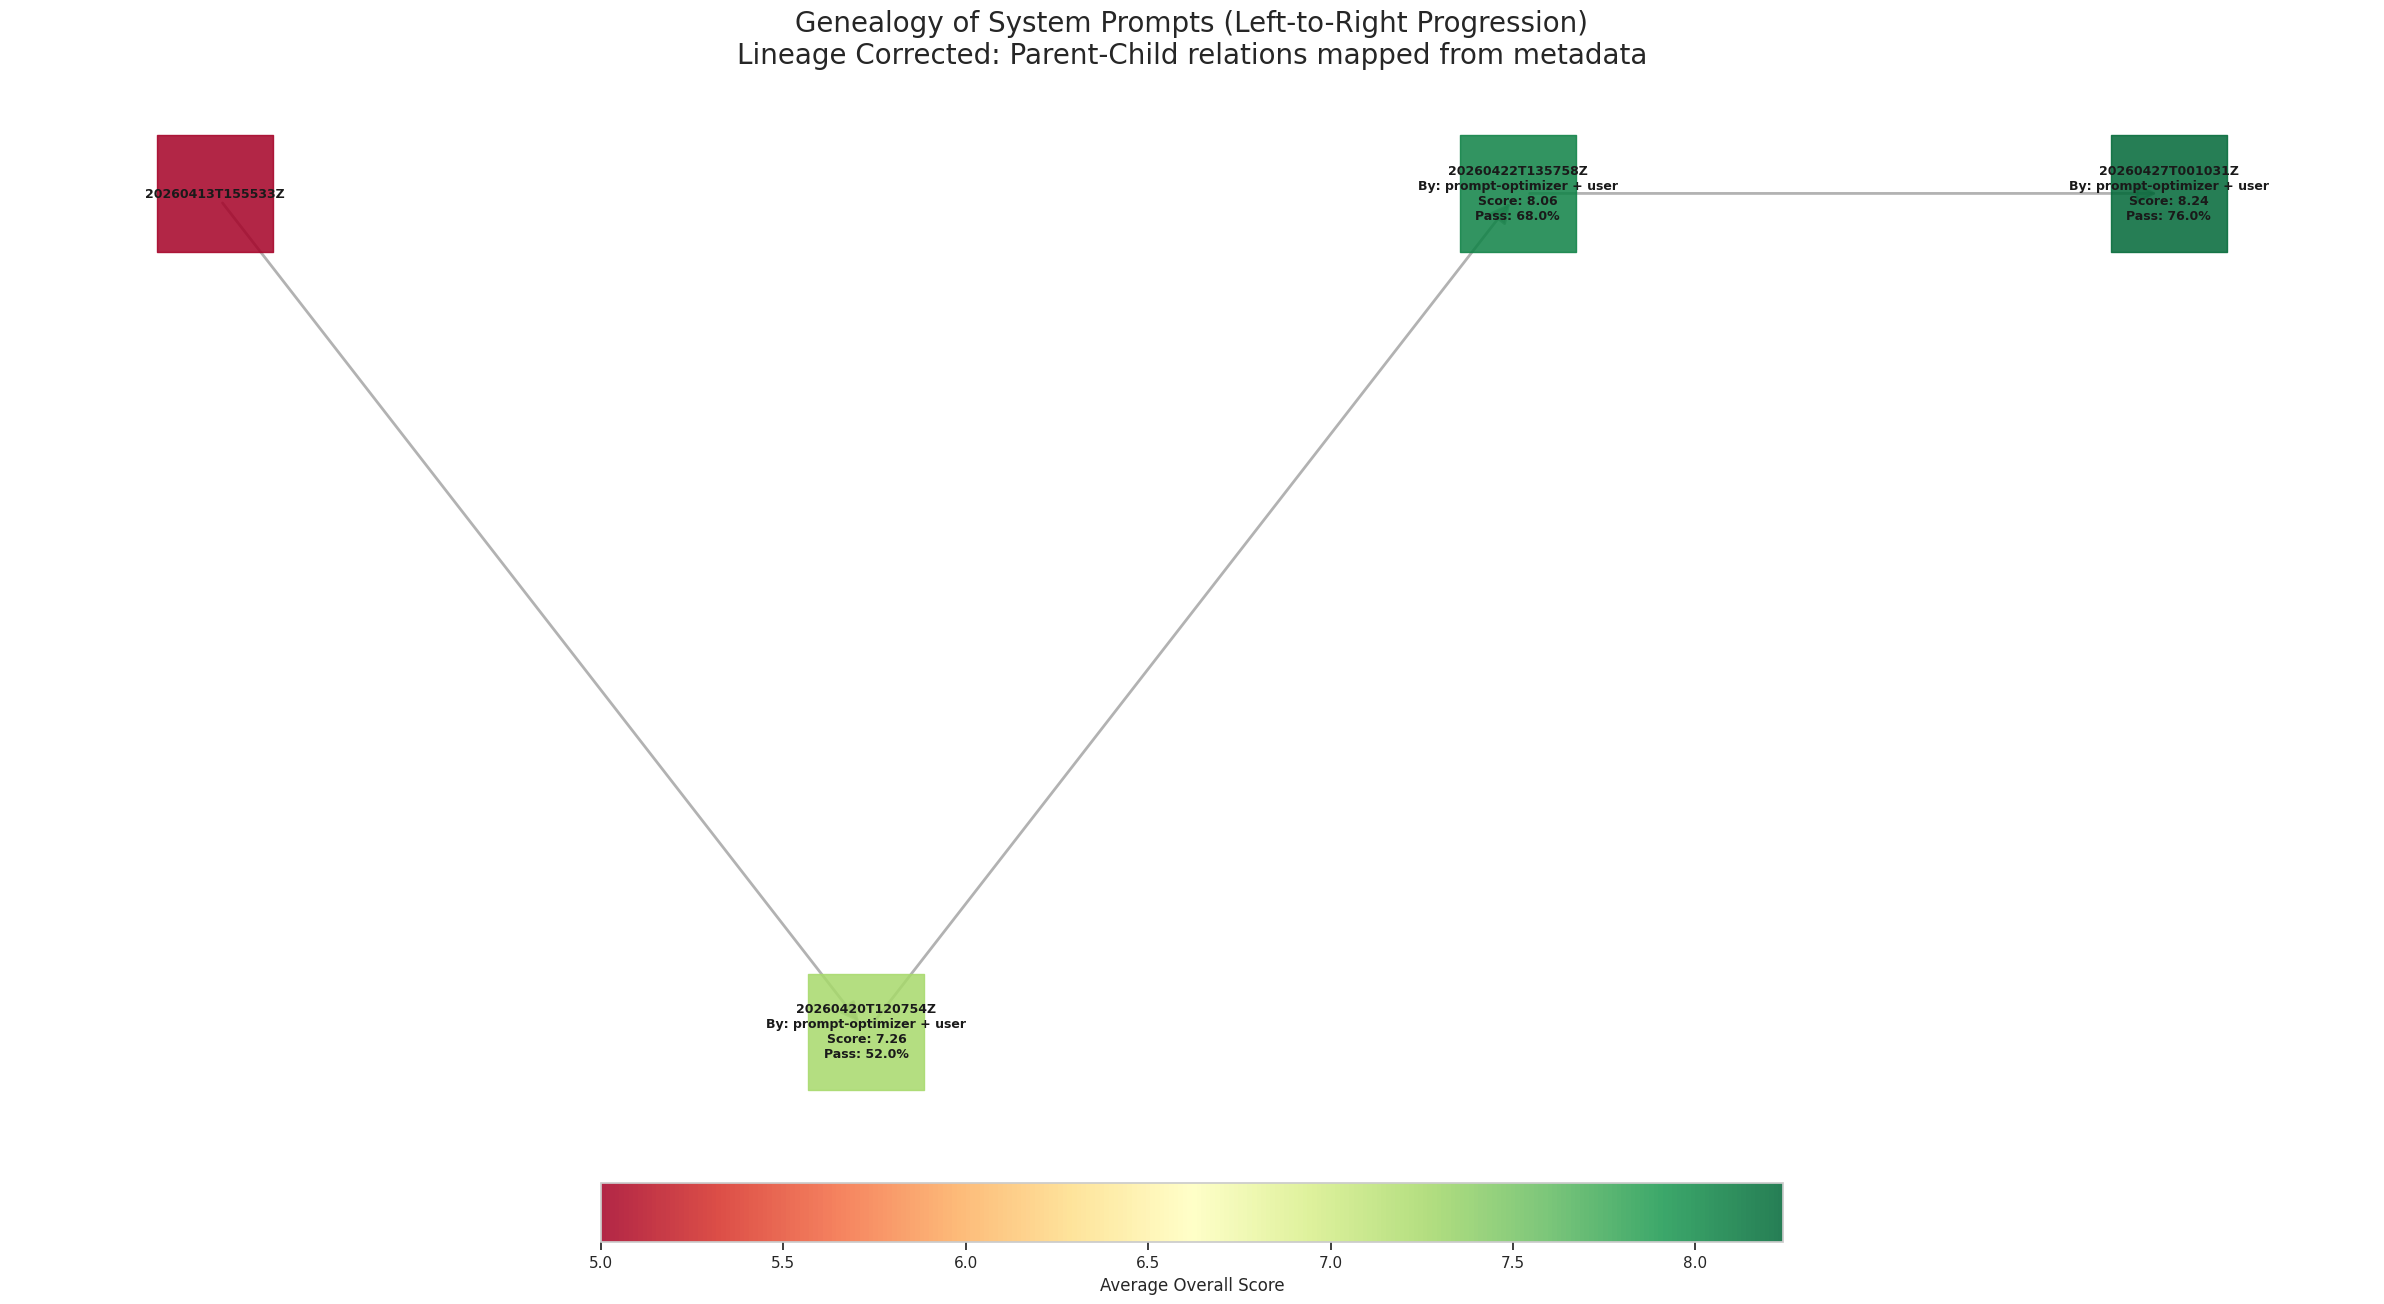

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Load the data files
df_raw = df 
df_meta = pd.read_csv('../output/system_prompts_chat.csv')

# 1. Clean metadata: Merge the two potential parent columns
# The colon at the end of 'remarks_optimized_from:' suggests a parsing artifact or intentional split
df_meta['parent_key'] = df_meta['remarks_optimized_from'].fillna(df_meta['remarks_optimized_from'])

# Verify the specific row the user mentioned
target_row = df_meta[df_meta['redis_key'] == latest_prompt]
print("Verification of target parent:")
print(target_row[['redis_key', 'parent_key']])

# 2. Filter performance data (N >= 25)
counts = df_raw['redis_optimization_reference'].value_counts()
valid_prompts = counts[counts >= 25].index
df_raw_filtered = df_raw[df_raw['redis_optimization_reference'].isin(valid_prompts)].copy()

# 3. Calculate metrics
perf_stats = df_raw_filtered.groupby('redis_optimization_reference').agg(
    pass_rate=('verdict', lambda x: (x == 'pass').mean()),
    avg_score=('overall_score', 'mean')
).reset_index()

# 4. Merge
df_tree_data = pd.merge(
    df_meta[['redis_key', 'remarks_created_by', 'parent_key']],
    perf_stats,
    left_on='redis_key',
    right_on='redis_optimization_reference',
    how='inner'
)

# 5. Build Graph
G = nx.DiGraph()
# Add all edges from meta to preserve lineage, even for nodes without metrics
for _, row in df_meta.iterrows():
    child = row['redis_key']
    parent = row['parent_key']
    if pd.notna(parent) and parent.strip() != "":
        G.add_edge(parent, child)

# 6. Position logic for Left-to-Right
def get_lr_pos(G):
    # Calculate level (X)
    levels = {}
    roots = [n for n, d in G.in_degree() if d == 0]
    for r in roots:
        for node, depth in nx.shortest_path_length(G, source=r).items():
            levels[node] = max(levels.get(node, 0), depth)
    
    # Calculate spread (Y)
    pos = {}
    level_counts = {}
    for node, level in sorted(levels.items(), key=lambda x: x[1]):
        level_counts[level] = level_counts.get(level, 0) + 1
        pos[node] = (level, -level_counts[level])
    return pos

pos = get_lr_pos(G)

# 7. Visualization
plt.figure(figsize=(24, 14))

# Only draw nodes that are in our performance dataset or are part of the direct lineage path
# For clarity, let's draw the nodes that have performance data
nodes_to_draw = [n for n in G.nodes() if n in df_tree_data['redis_key'].values]
# Add parents/ancestors of these nodes to ensure connections work
lineage_nodes = set(nodes_to_draw)
for n in nodes_to_draw:
    # Get ancestors
    if n in G:
        lineage_nodes.update(nx.ancestors(G, n))

# Filter G to just these nodes for a cleaner diagram
G_sub = G.subgraph(lineage_nodes)

# Prepare lists for drawing nodes with data vs placeholder nodes
node_colors = []
node_labels = {}
final_nodes_to_draw = list(G_sub.nodes())

for node in final_nodes_to_draw:
    if node in df_tree_data['redis_key'].values:
        row = df_tree_data[df_tree_data['redis_key'] == node].iloc[0]
        node_colors.append(row['avg_score'])
        name = node.split(':')[-1]
        creator = row['remarks_created_by'] if pd.notna(row['remarks_created_by']) else "unknown"
        node_labels[node] = f"{name}\nBy: {creator}\nScore: {row['avg_score']:.2f}\nPass: {row['pass_rate']:.1%}"
    else:
        node_colors.append(5.0) # Neutral score for placeholders
        node_labels[node] = node.split(':')[-1]

# Draw
nodes_plot = nx.draw_networkx_nodes(
    G_sub, pos, node_size=7000, 
    node_color=node_colors, cmap=plt.cm.RdYlGn, 
    alpha=0.85, node_shape='s'
)

nx.draw_networkx_edges(G_sub, pos, arrowstyle='-|>', arrowsize=30, edge_color='gray', width=2, alpha=0.6)
nx.draw_networkx_labels(G_sub, pos, labels=node_labels, font_size=9, font_weight='bold')

plt.title('Genealogy of System Prompts (Left-to-Right Progression)\nLineage Corrected: Parent-Child relations mapped from metadata', fontsize=20, pad=30)
plt.colorbar(nodes_plot, label='Average Overall Score', orientation='horizontal', shrink=0.5, pad=0.05)
plt.axis('off')
plt.tight_layout()
plt.savefig('corrected_genealogy_tree_lr.png')

# Output data verification
df_tree_data.to_csv('verified_genealogy_data.csv', index=False)
print("\nFinal Data Mapping:")
print(df_tree_data[['redis_key', 'parent_key', 'avg_score']])

Mapping verification:
Node: 20260420T120754Z | Generation: 1 | Score: 7.26
Node: 20260422T135758Z | Generation: 2 | Score: 8.06
Node: 20260427T001031Z | Generation: 3 | Score: 8.24


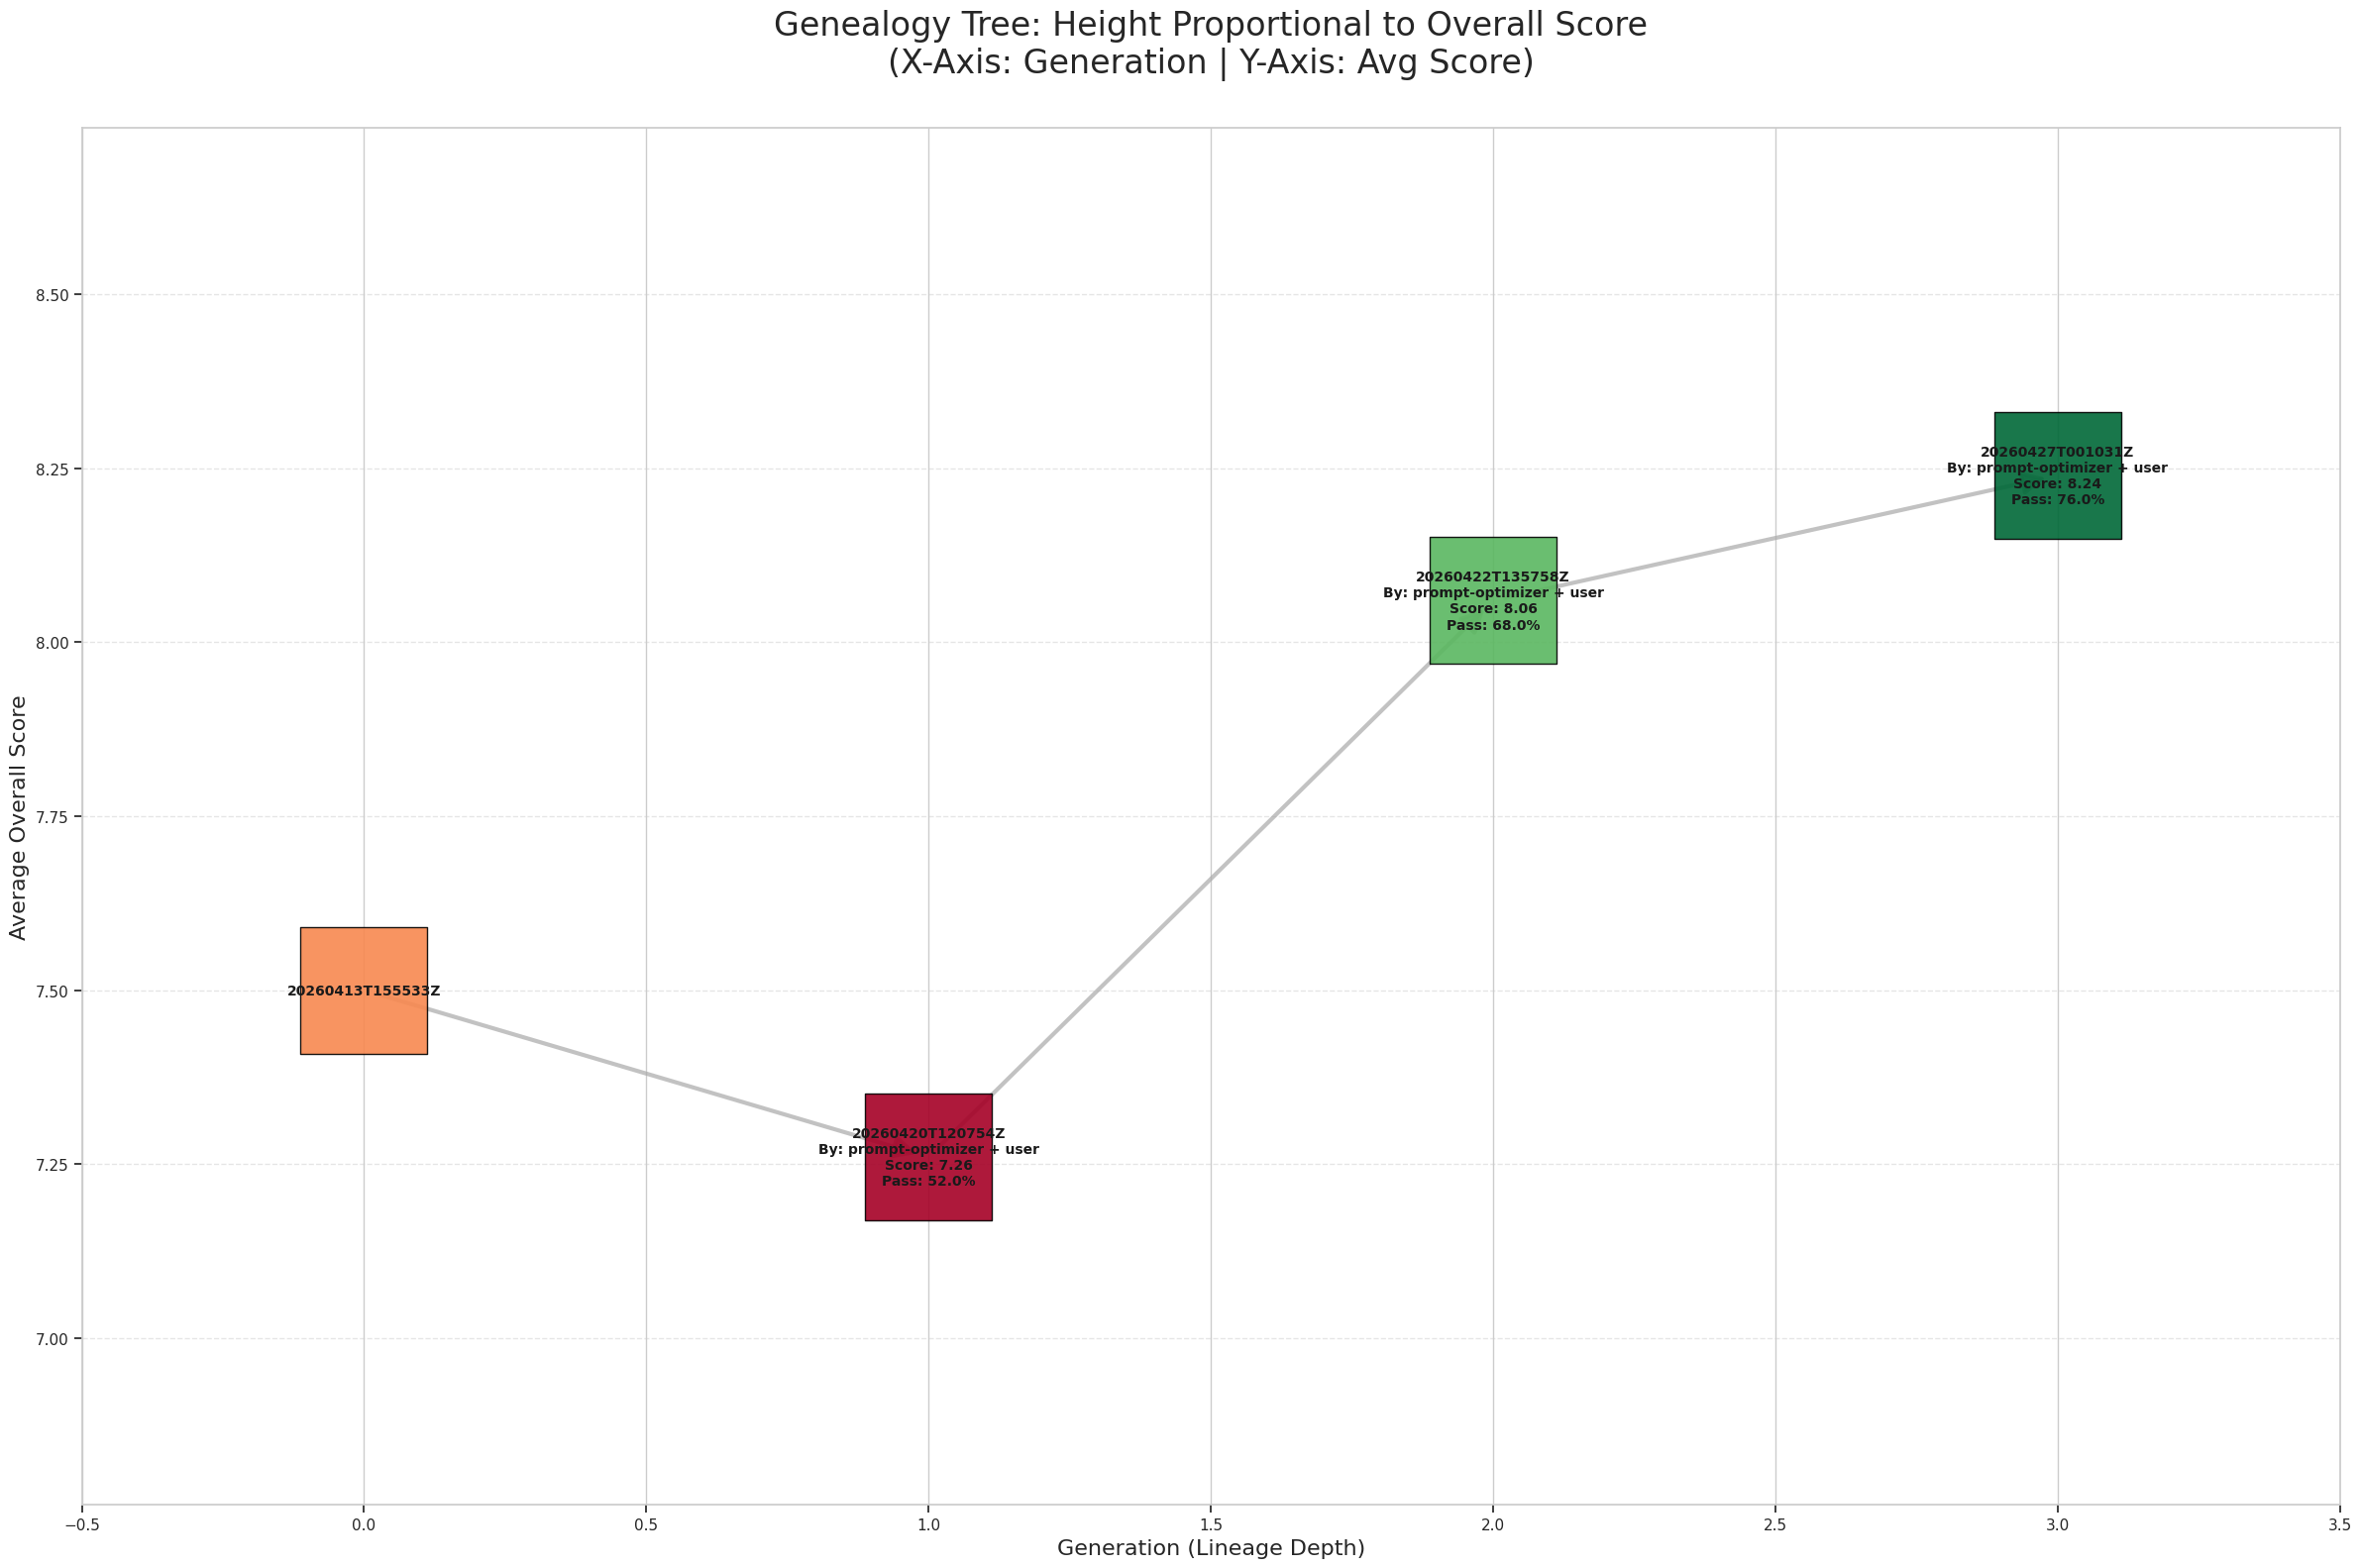

In [9]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Load files

# Pre-processing metadata for Genealogy
def get_parent(row):
    p1 = str(row['remarks_optimized_from']).strip() if pd.notna(row['remarks_optimized_from']) else ""
    p2 = str(row['remarks_optimized_from']).strip() if pd.notna(row['remarks_optimized_from']) else ""
    return p2 if p2 != "" else p1

df_meta['parent_key'] = df_meta.apply(get_parent, axis=1)

# Filter performance data (N >= 25)
counts = df_raw['redis_optimization_reference'].value_counts()
valid_prompts = counts[counts >= 25].index
df_raw_filtered = df_raw[df_raw['redis_optimization_reference'].isin(valid_prompts)].copy()

# Metrics
perf_stats = df_raw_filtered.groupby('redis_optimization_reference').agg(
    pass_rate=('verdict', lambda x: (x == 'pass').mean()),
    avg_score=('overall_score', 'mean')
).reset_index()

# Merge
df_merged = pd.merge(
    df_meta[['redis_key', 'remarks_created_by', 'parent_key']],
    perf_stats,
    left_on='redis_key',
    right_on='redis_optimization_reference',
    how='inner'
)

# Build Genealogy Graph
G = nx.DiGraph()
# Add edges from meta
for _, row in df_meta.iterrows():
    child = row['redis_key']
    parent = row['parent_key']
    if pd.notna(parent) and parent != "":
        G.add_edge(parent, child)

# Filter Graph to only nodes with data
nodes_with_data = set(df_merged['redis_key'])
# To make a continuous tree, include ancestors of nodes with data
lineage_nodes = set(nodes_with_data)
for n in nodes_with_data:
    if n in G:
        lineage_nodes.update(nx.ancestors(G, n))
G_sub = G.subgraph(lineage_nodes)

# Position Logic: 
# X = Depth (Generation)
# Y = Average Score
def get_score_layered_pos(G, score_map):
    # Determine depth from roots
    roots = [n for n, d in G.in_degree() if d == 0]
    depths = {}
    for r in roots:
        d = nx.shortest_path_length(G, source=r)
        for node, val in d.items():
            depths[node] = max(depths.get(node, 0), val)
    
    pos = {}
    for node in G.nodes():
        x = depths.get(node, 0)
        # Use score for Y if available, else use a placeholder or parent's score
        y = score_map.get(node, 7.5) # Default/Base score if no data
        pos[node] = (x, y)
    return pos

# Create score map for positioning
score_map = dict(zip(df_merged['redis_key'], df_merged['avg_score']))
# For nodes without direct scores in df_merged, try to infer or use base
# Let's just use the df_merged keys for the map.

pos = get_score_layered_pos(G_sub, score_map)

# Visualization
plt.figure(figsize=(24, 16))

node_colors = []
node_labels = {}
all_nodes = list(G_sub.nodes())

for node in all_nodes:
    if node in nodes_with_data:
        row = df_merged[df_merged['redis_key'] == node].iloc[0]
        node_colors.append(row['avg_score'])
        name = node.split(':')[-1]
        creator = row['remarks_created_by'] if pd.notna(row['remarks_created_by']) else "unknown"
        node_labels[node] = f"{name}\nBy: {creator}\nScore: {row['avg_score']:.2f}\nPass: {row['pass_rate']:.1%}"
    else:
        node_colors.append(7.5) # Neutral for placeholders
        node_labels[node] = node.split(':')[-1]

# Draw nodes
nodes_plot = nx.draw_networkx_nodes(
    G_sub, pos, node_size=8500, 
    node_color=node_colors, cmap=plt.cm.RdYlGn, 
    alpha=0.9, node_shape='s', edgecolors='black'
)

# Draw connections
nx.draw_networkx_edges(G_sub, pos, arrowstyle='-|>', arrowsize=35, edge_color='darkgrey', alpha=0.7, width=3)

# Draw labels
nx.draw_networkx_labels(G_sub, pos, labels=node_labels, font_size=10, font_weight='bold')

plt.title('Genealogy Tree: Height Proportional to Overall Score\n(X-Axis: Generation | Y-Axis: Avg Score)', fontsize=24, pad=40)
plt.xlabel('Generation (Lineage Depth)', fontsize=16)
plt.ylabel('Average Overall Score', fontsize=16)

# Add y-axis grid to emphasize score proportionality
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

# Set axes limits for better viewing
scores = [pos[n][1] for n in all_nodes]
plt.ylim(min(scores) - 0.5, max(scores) + 0.5)
plt.xlim(-0.5, max([pos[n][0] for n in all_nodes]) + 0.5)

plt.tight_layout()
plt.savefig('genealogy_tree_score_proportional.png')

print("Mapping verification:")
for n in all_nodes:
    if n in nodes_with_data:
        print(f"Node: {n.split(':')[-1]} | Generation: {pos[n][0]} | Score: {pos[n][1]:.2f}")

Mapping verification (Pass Rate):
Node: 20260420T120754Z | Gen: 1 | Pass Rate: 52.0%
Node: 20260422T135758Z | Gen: 2 | Pass Rate: 68.0%
Node: 20260427T001031Z | Gen: 3 | Pass Rate: 76.0%


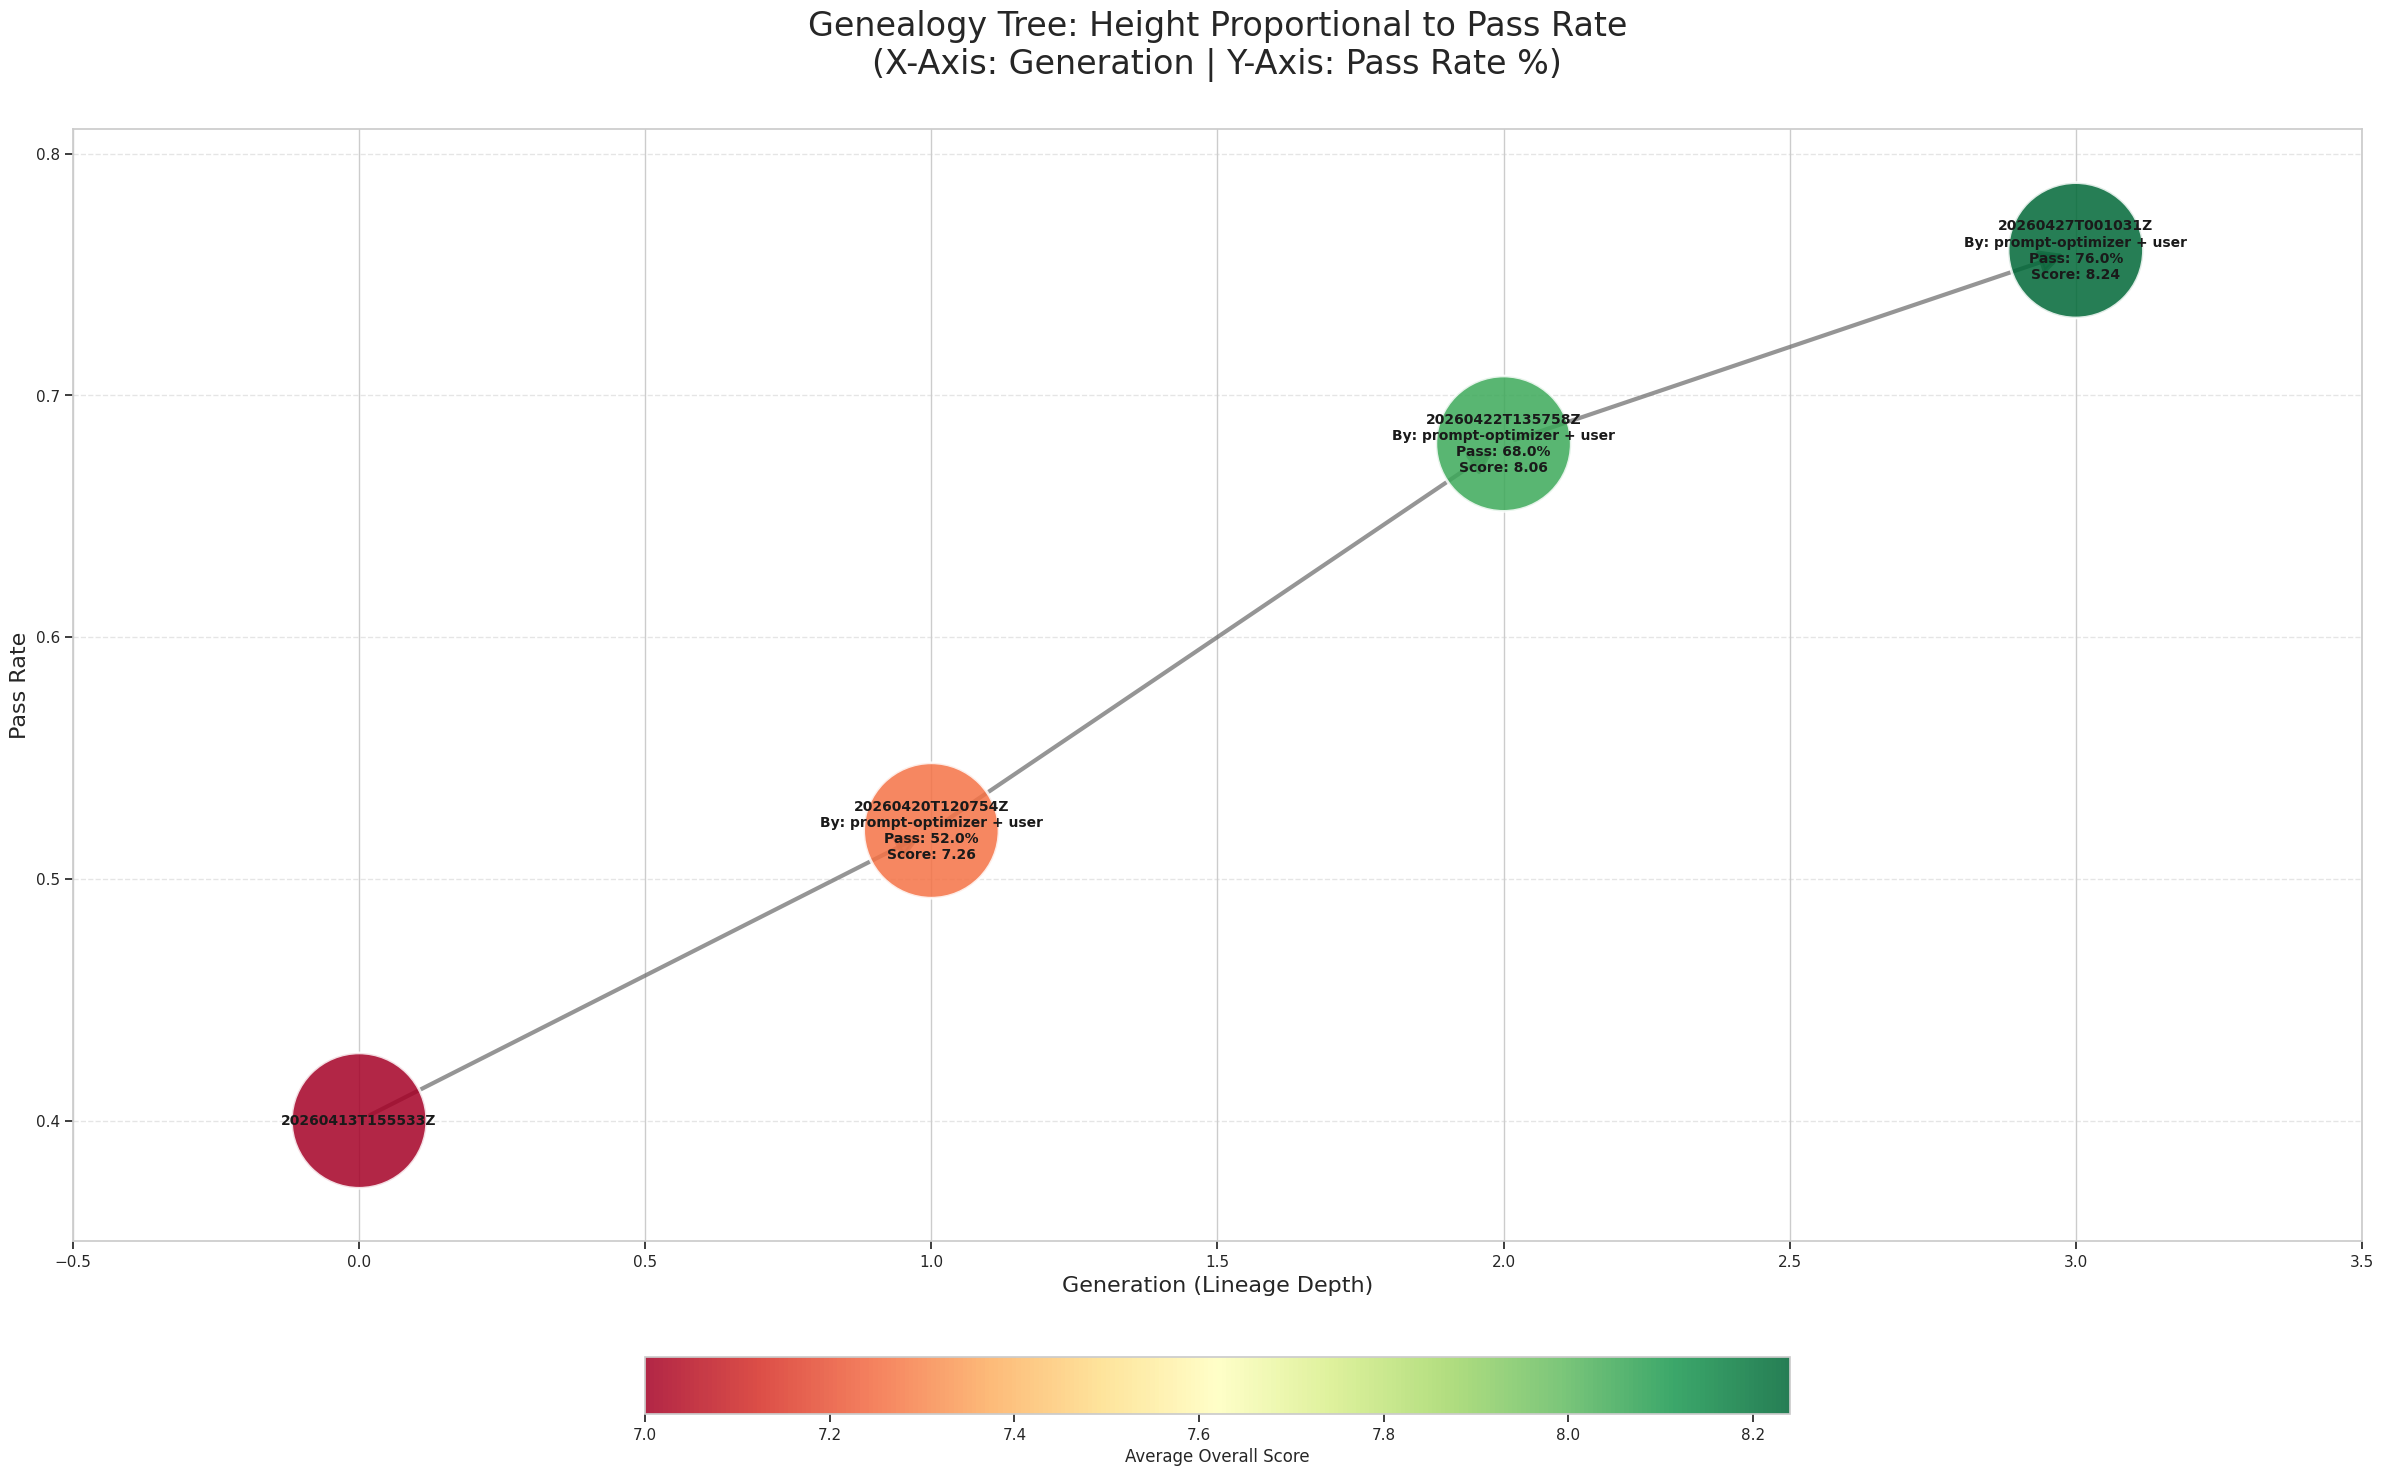

In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Load files

# Pre-processing metadata for Genealogy
# Merge the two parent columns as identified previously
def get_parent(row):
    p1 = str(row['remarks_optimized_from']).strip() if pd.notna(row['remarks_optimized_from']) else ""
    p2 = str(row['remarks_optimized_from']).strip() if pd.notna(row['remarks_optimized_from']) else ""
    return p2 if p2 != "" else p1

df_meta['parent_key'] = df_meta.apply(get_parent, axis=1)

# Filter performance data (N >= 25)
counts = df_raw['redis_optimization_reference'].value_counts()
valid_prompts = counts[counts >= 25].index
df_raw_filtered = df_raw[df_raw['redis_optimization_reference'].isin(valid_prompts)].copy()

# Calculate Performance Metrics
perf_stats = df_raw_filtered.groupby('redis_optimization_reference').agg(
    pass_rate=('verdict', lambda x: (x == 'pass').mean()),
    avg_score=('overall_score', 'mean')
).reset_index()

# Merge metrics into metadata
df_merged = pd.merge(
    df_meta[['redis_key', 'remarks_created_by', 'parent_key']],
    perf_stats,
    left_on='redis_key',
    right_on='redis_optimization_reference',
    how='inner'
)

# Build Genealogy Graph
G = nx.DiGraph()
for _, row in df_meta.iterrows():
    child = row['redis_key']
    parent = row['parent_key']
    if pd.notna(parent) and parent != "":
        G.add_edge(parent, child)

# Identify nodes with data and their ancestors for a complete tree
nodes_with_data = set(df_merged['redis_key'])
lineage_nodes = set(nodes_with_data)
for n in nodes_with_data:
    if n in G:
        lineage_nodes.update(nx.ancestors(G, n))
G_sub = G.subgraph(lineage_nodes)

# Position Logic:
# X = Depth (Generation)
# Y = Pass Rate
def get_pass_rate_layered_pos(G, pass_rate_map):
    # Determine depth from roots
    roots = [n for n, d in G.in_degree() if d == 0]
    depths = {}
    for r in roots:
        try:
            d_map = nx.shortest_path_length(G, source=r)
            for node, val in d_map.items():
                depths[node] = max(depths.get(node, 0), val)
        except:
            continue
    
    pos = {}
    for node in G.nodes():
        x = depths.get(node, 0)
        # Use pass_rate for Y if available
        # If node is a placeholder (ancestor with no data), we default to a baseline or parent value
        y = pass_rate_map.get(node, 0.4) # Default placeholder pass rate
        pos[node] = (x, y)
    return pos

# Create map for Y positioning
pass_rate_map = dict(zip(df_merged['redis_key'], df_merged['pass_rate']))
pos = get_pass_rate_layered_pos(G_sub, pass_rate_map)

# Visualization
plt.figure(figsize=(24, 16))

node_colors = []
node_labels = {}
all_nodes = list(G_sub.nodes())

for node in all_nodes:
    if node in nodes_with_data:
        row = df_merged[df_merged['redis_key'] == node].iloc[0]
        # Keep coloring by avg_score for dual-metric insight
        node_colors.append(row['avg_score'])
        name = node.split(':')[-1]
        creator = row['remarks_created_by'] if pd.notna(row['remarks_created_by']) else "unknown"
        node_labels[node] = f"{name}\nBy: {creator}\nPass: {row['pass_rate']:.1%}\nScore: {row['avg_score']:.2f}"
    else:
        node_colors.append(7.0) # Neutral for placeholders
        node_labels[node] = node.split(':')[-1]

# Draw nodes
# Updated node drawing logic
nodes_plot = nx.draw_networkx_nodes(
    G_sub, 
    pos, 
    node_size=9500,            # Slightly larger to accommodate text in circles
    node_color=node_colors, 
    cmap=plt.cm.RdYlGn,        
    alpha=0.85,               # Slightly softer transparency
    node_shape='o',           # 'o' for circle
    edgecolors='#ffffff',     # White border for a "floating" look
    linewidths=2              # Subtle border width
)

# Optional: Adjust label font size if it feels tight in the circles
# nx.draw_networkx_labels(
#     G_sub, 
#     pos, 
#     labels=node_labels, 
#     font_size=9,              # Slightly smaller font helps fit inside circles
#     font_weight='bold',
#     font_color='#2c3e50'      # Dark grey instead of pure black for a softer look
# )

# Draw connections
nx.draw_networkx_edges(G_sub, pos, arrowstyle='-|>', arrowsize=35, edge_color='dimgrey', alpha=0.7, width=3)

# Draw labels
nx.draw_networkx_labels(G_sub, pos, labels=node_labels, font_size=10, font_weight='bold')

plt.title('Genealogy Tree: Height Proportional to Pass Rate\n(X-Axis: Generation | Y-Axis: Pass Rate %)', fontsize=24, pad=40)
plt.xlabel('Generation (Lineage Depth)', fontsize=16)
plt.ylabel('Pass Rate', fontsize=16)

# Formatting axes
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

# Set axes limits
pass_rates = [pos[n][1] for n in all_nodes]
plt.ylim(min(pass_rates) - 0.05, max(pass_rates) + 0.05)
plt.xlim(-0.5, max([pos[n][0] for n in all_nodes]) + 0.5)

# Colorbar for the score
plt.colorbar(nodes_plot, label='Average Overall Score', orientation='horizontal', shrink=0.5, pad=0.08)

plt.tight_layout()
plt.savefig('genealogy_tree_pass_rate_proportional.png')

# Mapping verification for text response
print("Mapping verification (Pass Rate):")
for n in sorted(all_nodes, key=lambda x: pos[x][0]):
    if n in nodes_with_data:
        print(f"Node: {n.split(':')[-1]} | Gen: {pos[n][0]} | Pass Rate: {pos[n][1]:.1%}")

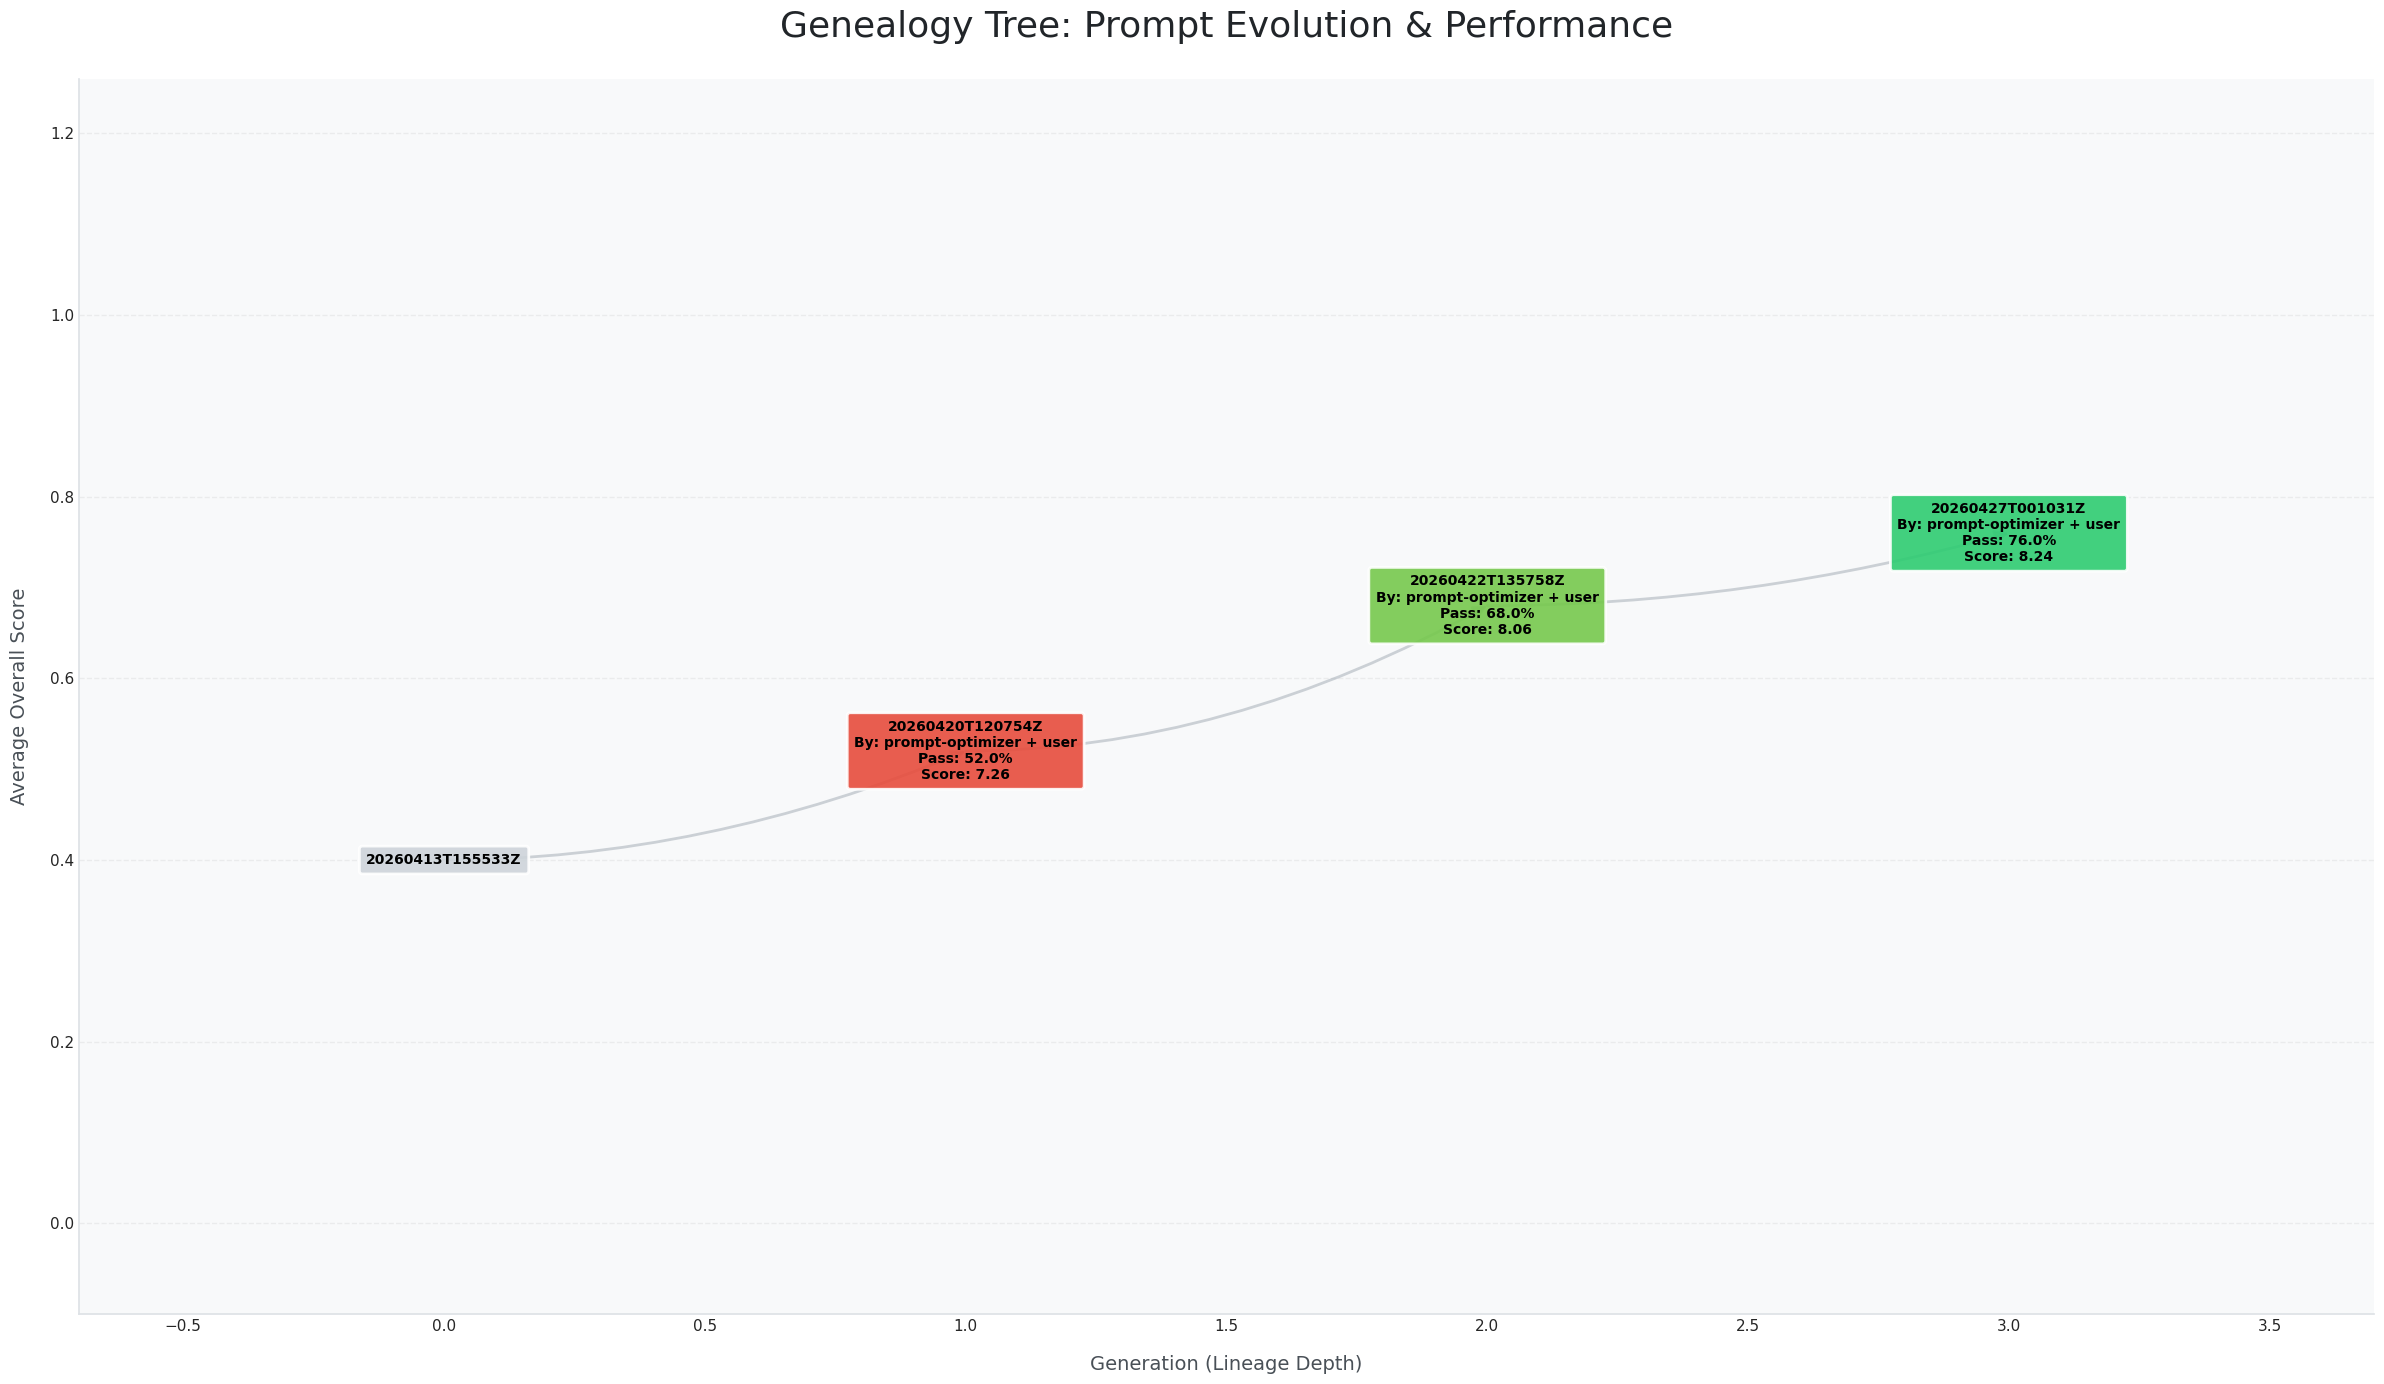

In [11]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# ... (Keep your data processing code the same until the Visualization section) ...

# 1. Setup Style & Color Palette
plt.style.use('seaborn-v0_8-white') # Cleaner background
custom_cmap = LinearSegmentedColormap.from_list("soft_gen", ["#e74c3c", "#f1c40f", "#2ecc71"])

fig, ax = plt.subplots(figsize=(24, 14))
ax.set_facecolor('#f8f9fa')

# 2. Draw Nodes with Rounded Bboxes
for node, (x, y) in pos.items():
    if node in nodes_with_data:
        row = df_merged[df_merged['redis_key'] == node].iloc[0]
        score = row['avg_score']
        color = custom_cmap((score - min(score_map.values())) / (max(score_map.values()) - min(score_map.values())))
        label = node_labels[node]
    else:
        color = '#ced4da' # Soft grey for placeholders
        label = node_labels[node]

    # Use FancyBboxPatch for rounded corners
    bbox_props = dict(boxstyle="round,pad=0.5,rounding_size=0.2", 
                      facecolor=color, edgecolor='white', linewidth=2, alpha=0.9)
    
    ax.text(x, y, label, ha='center', va='center', fontsize=10, 
            fontweight='bold', color='black', bbox=bbox_props, zorder=3)

# 3. Draw Smooth Curved Edges
for u, v in G_sub.edges():
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    
    # Create a Bezier curve path
    path_data = [
        (patches.Path.MOVETO, (x1, y1)),
        (patches.Path.CURVE3, (x1 + (x2-x1)/2, y1)), # Control point
        (patches.Path.CURVE3, (x2, y2)),
    ]
    codes, verts = zip(*path_data)
    path = patches.Path(verts, codes)
    
    # Add the curve to the plot
    patch = patches.FancyArrowPatch(path=path, color='#adb5bd', arrowstyle='-|>', 
                                    mutation_scale=20, lw=2, alpha=0.6, zorder=1)
    ax.add_patch(patch)

# 4. Refined Formatting
ax.set_title('Genealogy Tree: Prompt Evolution & Performance', fontsize=26, fontweight='300', pad=30, color='#212529')
ax.set_xlabel('Generation (Lineage Depth)', fontsize=14, labelpad=15, color='#495057')
ax.set_ylabel('Average Overall Score', fontsize=14, labelpad=15, color='#495057')

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dee2e6')
ax.spines['bottom'].set_color('#dee2e6')

ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)

# Set limits based on data
all_x = [p[0] for p in pos.values()]
all_y = [p[1] for p in pos.values()]
ax.set_xlim(min(all_x) - 0.7, max(all_x) + 0.7)
ax.set_ylim(min(all_y) - 0.5, max(all_y) + 0.5)

plt.tight_layout()
plt.show()